In [3]:
import zipfile

with zipfile.ZipFile("archive (8).zip", 'r') as zip_ref:
    zip_ref.extractall("movies_data")

print("Extraction Done ✅")

Extraction Done ✅


In [4]:
import os
os.listdir("movies_data")

['imdb_top_1000.csv']

In [5]:
#load dataset
import pandas as pd

df = pd.read_csv("movies_data/imdb_top_1000.csv")

df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [6]:
#Column Names Check
df.columns


Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

In [7]:
#Basic Info & Missing Values Check
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


Poster_Link        0
Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Overview           0
Meta_score       157
Director           0
Star1              0
Star2              0
Star3              0
Star4              0
No_of_Votes        0
Gross            169
dtype: int64

In [8]:
#Clean Data
#Duplicates remove
df = df.drop_duplicates()

In [9]:
df = df.dropna(subset=['IMDB_Rating', 'Genre'])

In [10]:
#Summary Statistics
print("Mean Rating:", df['IMDB_Rating'].mean())
print("Median Rating:", df['IMDB_Rating'].median())
print("Mode Rating:", df['IMDB_Rating'].mode()[0])

Mean Rating: 7.949299999999999
Median Rating: 7.9
Mode Rating: 7.7


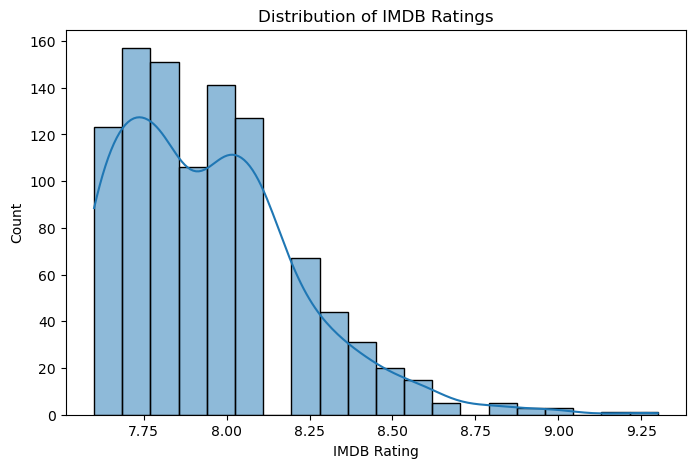

In [11]:
#Histogram (Rating Distribution)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['IMDB_Rating'], bins=20, kde=True)
plt.title("Distribution of IMDB Ratings")
plt.xlabel("IMDB Rating")
plt.ylabel("Count")
plt.show()

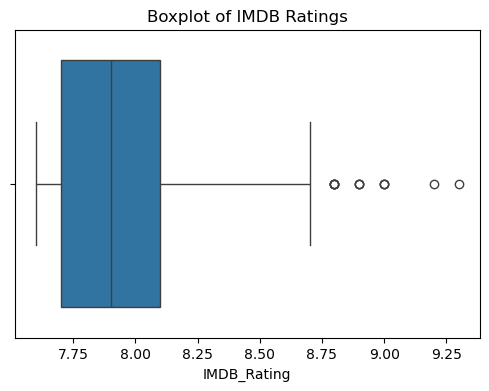

In [12]:
#Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['IMDB_Rating'])
plt.title("Boxplot of IMDB Ratings")
plt.show()

In [13]:
#Top 10 Rated Movies
top_movies = df.sort_values(by='IMDB_Rating', ascending=False).head(10)

top_movies[['Series_Title', 'IMDB_Rating']]

,Series_Title,IMDB_Rating
0,The Shawshank Redemption,9.3
1,The Godfather,9.2
2,The Dark Knight,9.0
3,The Godfather: Part II,9.0
4,12 Angry Men,9.0
5,The Lord of the Rings: The Return of the King,8.9
6,Pulp Fiction,8.9
7,Schindler's List,8.9
10,The Lord of the Rings: The Fellowship of the Ring,8.8
11,Forrest Gump,8.8


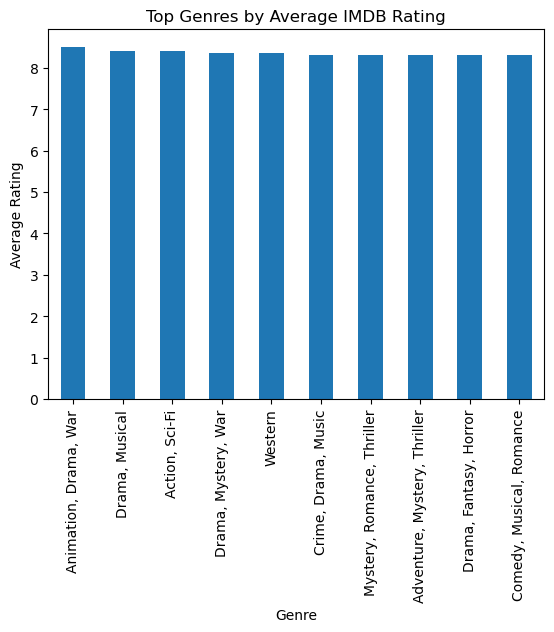

In [14]:
#Genre Analysis (Average Rating by Genre)
genre_avg = df.groupby('Genre')['IMDB_Rating'].mean().sort_values(ascending=False)

genre_avg.head(10)

#graph
genre_avg.head(10).plot(kind='bar')
plt.title("Top Genres by Average IMDB Rating")
plt.ylabel("Average Rating")
plt.show()


In [15]:
df.to_csv("cleaned_imdb.csv", index=False)

print("File Saved Successfully ✅")

File Saved Successfully ✅


In [16]:
import os
os.listdir()

['.anaconda',
 '.conda',
 '.condarc',
 '.continuum',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.python_history',
 '.spyder-py3',
 '.vscode',
 '.vscode-shared',
 'anaconda_projects',
 'AppData',
 'Application Data',
 'archive (8).zip',
 'battery-report.html',
 'cleaned_imdb.csv',
 'Contacts',
 'Cookies',
 'Documents',
 'Downloads',
 'Favorites',
 'IntelGraphicsProfiles',
 'Links',
 'Local Settings',
 'Movie Rating Analysis.ipynb',
 'movies_data',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'Pictures',
 'PrintHood',
 'Recent',
 'Saved Games',
 'Searches',
 'SendTo',
 'Start Menu',
 'task',
 'task.ipynb',
 'Templates',
 'Unti

In [20]:
import os
os.path.expanduser("~")

'C:\\Users\\DELL'

In [21]:
df.to_csv("C:/Users/DELL/Documents/cleaned_imdb.csv", index=False)
print("Saved to Documents ✅")

Saved to Documents ✅
